In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data")

print("Path to dataset files:", path)

100%|██████████| 1.78G/1.78G [00:36<00:00, 52.6MB/s]

Extracting files...


Path to dataset files: C:\Users\000010478\.cache\kagglehub\datasets\elemento\nyc-yellow-taxi-trip-data\versions\2


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Directorio donde están los CSV
directorio = Path(path)      # Cambia por tu ruta

# Lista de DataFrames
dfs = []

# Cargar todos los CSV
for archivo in directorio.glob("*.csv"):
    df = pd.read_csv(archivo)
    dfs.append(df)

print(f"Se cargaron {len(dfs)} archivos.")

Se cargaron 4 archivos.


In [47]:
data=pd.concat(dfs, ignore_index=True) #Se concatenan los dataframes para ser uno solo
data.sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID
19510136,1,2016-01-19 15:11:01,2016-01-19 15:17:24,1,0.40,-73.975922,40.755119,NaN,N,-73.971352,40.761398,1,5.5,0.0,0.5,1.25,0.00,0.3,7.55,1.0
23828607,2,2016-02-01 12:54:37,2016-02-01 13:37:41,1,11.50,-73.874413,40.774025,NaN,N,-73.989914,40.757496,1,39.5,0.0,0.5,5.00,5.54,0.3,50.84,1.0
46829133,2,2016-03-30 22:43:05,2016-03-30 23:04:14,1,3.72,-73.997513,40.725601,NaN,N,-73.983559,40.766949,1,16.5,0.5,0.5,3.56,0.00,0.3,21.36,1.0
45298715,2,2016-03-26 19:24:30,2016-03-26 20:00:41,1,10.54,-73.981888,40.780392,NaN,N,-73.979797,40.677319,1,34.5,0.0,0.5,8.17,5.54,0.3,49.01,1.0
46946059,1,2016-03-31 09:32:13,2016-03-31 09:48:35,1,1.50,-73.949112,40.773228,NaN,N,-73.967957,40.765125,1,11.5,0.0,0.5,2.00,0.00,0.3,14.30,1.0
38876774,2,2016-03-08 22:21:59,2016-03-08 22:23:58,3,0.39,-73.946121,40.789494,NaN,N,-73.945007,40.786907,2,3.5,0.5,0.5,0.00,0.00,0.3,4.80,1.0
647533,1,2015-01-05 07:44:03,2015-01-05 07:44:44,1,0.10,-73.929077,40.768478,1.0,N,-73.929794,40.767506,2,2.5,0.0,0.5,0.00,0.00,0.3,3.30,NaN
4368929,2,2015-01-29 08:06:27,2015-01-29 08:14:12,2,0.80,-73.964851,40.755733,1.0,N,-73.975105,40.757935,2,6.5,0.0,0.5,0.00,0.00,0.3,7.30,NaN
28145443,2,2016-02-09 10:06:25,2016-02-09 10:22:57,1,1.78,-73.994080,40.751186,NaN,N,-73.973007,40.758545,1,11.5,0.0,0.5,2.46,0.00,0.3,14.76,1.0
9298811,2,2015-01-07 11:11:01,2015-01-07 11:21:14,1,1.18,-73.956253,40.778831,1.0,N,-73.966629,40.763321,2,8.0,0.0,0.5,0.00,0.00,0.3,8.80,NaN


In [48]:
#Revisión de los datos para poder procesarlos
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 47248845 entries, 0 to 47248844
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             float64
 8   store_and_fwd_flag     str    
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
 19  RatecodeID             float64
dtypes: float64(14), int64(3), str(3)
memory usage: 8.8 GB


In [49]:
#Vamos a convertir las fechas y extraer información como día de la semana, hora del día y mes del año. Esto nos permitirá analizar los datos de manera más efectiva.
data["tpep_pickup_datetime"] = pd.to_datetime(data["tpep_pickup_datetime"])
data["tpep_dropoff_datetime"] = pd.to_datetime(data["tpep_dropoff_datetime"])
data["day_of_week"] = data["tpep_pickup_datetime"].dt.dayofweek
data["hour_of_day"] = data["tpep_pickup_datetime"].dt.hour
data["month"] = data["tpep_pickup_datetime"].dt.month
data.sample(10)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID,day_of_week,hour_of_day,month
18252582,1,2016-01-17 13:58:38,2016-01-17 14:08:00,1,2.00,-73.948380,40.774437,NaN,N,-73.967979,...,0.0,0.5,1.95,0.0,0.3,11.75,1.0,6,13,1
3138562,2,2015-01-30 01:46:11,2015-01-30 01:53:16,1,1.15,-73.996330,40.724041,1.0,N,-74.008339,...,0.5,0.5,1.66,0.0,0.3,9.96,NaN,4,1,1
8378497,2,2015-01-15 20:24:16,2015-01-15 20:25:42,1,0.41,-73.955490,40.779812,1.0,N,-73.958504,...,0.5,0.5,1.11,0.0,0.3,5.91,NaN,3,20,1
16998921,1,2016-01-14 12:07:34,2016-01-14 12:19:11,1,1.60,-73.964813,40.760223,NaN,N,-73.974876,...,0.0,0.5,0.00,0.0,0.3,9.80,1.0,3,12,1
41965696,1,2016-03-21 09:09:23,2016-03-21 09:31:22,1,5.30,-73.991127,40.717243,NaN,N,-73.971390,...,0.0,0.5,2.00,0.0,0.3,22.80,1.0,0,9,3
20773852,2,2016-01-31 22:19:21,2016-01-31 22:26:44,1,1.51,-74.003151,40.748062,NaN,N,-73.983971,...,0.5,0.5,1.66,0.0,0.3,9.96,1.0,6,22,1
29179139,1,2016-02-17 21:12:21,2016-02-17 21:17:15,1,0.00,-73.975883,40.765713,NaN,N,-73.974709,...,0.5,0.5,0.00,0.0,0.3,3.80,1.0,2,21,2
22942728,2,2016-01-07 19:16:42,2016-01-07 19:38:35,1,2.57,-73.950729,40.779259,NaN,N,-73.982140,...,1.0,0.5,3.36,0.0,0.3,20.16,1.0,3,19,1
42131827,1,2016-03-21 18:14:09,2016-03-21 18:28:03,1,2.40,-73.945992,40.792587,NaN,N,-73.953156,...,1.0,0.5,0.00,0.0,0.3,13.30,1.0,0,18,3
37651237,1,2016-03-06 23:07:11,2016-03-06 23:24:05,2,8.20,-73.988434,40.743366,NaN,N,-73.943733,...,0.5,0.5,6.45,0.0,0.3,32.25,1.0,6,23,3


In [50]:
#Campo de duración del viaje
data["trip_duration"] = (data["tpep_dropoff_datetime"] - data["tpep_pickup_datetime"]).dt.total_seconds() / 60  # Duración en minutos
data.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID,day_of_week,hour_of_day,month,trip_duration
count,4.724884e+07,47248845,47248845,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,1.274899e+07,4.724884e+07,4.724884e+07,...,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,3.449986e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07
mean,1.529570e+00,2015-11-01 19:34:22.551143,2015-11-01 19:49:31.111697,1.667040e+00,7.508418e+00,-7.276452e+01,4.008470e+01,1.036901e+00,-7.282501e+01,4.011889e+01,...,4.977081e-01,1.794568e+00,2.843674e-01,2.952466e-01,1.559273e+01,1.039150e+00,3.100029e+00,1.362430e+01,1.757774e+00,1.514268e+01
min,1.000000e+00,2015-01-01 00:00:00,2015-01-01 00:00:00,0.000000e+00,-3.390584e+06,-1.616987e+02,-7.703949e+01,1.000000e+00,-7.401667e+02,-7.703949e+01,...,-1.000000e+00,-2.208000e+02,-9.999000e+01,-3.000000e-01,-9.584000e+02,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,-5.371001e+05
25%,1.000000e+00,2015-01-30 07:34:06,2015-01-30 07:47:19,1.000000e+00,1.000000e+00,-7.399166e+01,4.073611e+01,1.000000e+00,-7.399120e+01,4.073459e+01,...,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.300000e+00,1.000000e+00,1.000000e+00,9.000000e+00,1.000000e+00,6.316667e+00
50%,2.000000e+00,2016-01-31 21:20:27,2016-01-31 21:35:50,1.000000e+00,1.690000e+00,-7.398155e+01,4.075335e+01,1.000000e+00,-7.397962e+01,4.075380e+01,...,5.000000e-01,1.250000e+00,0.000000e+00,3.000000e-01,1.160000e+01,1.000000e+00,3.000000e+00,1.400000e+01,1.000000e+00,1.045000e+01
75%,2.000000e+00,2016-03-02 05:54:00,2016-03-02 06:08:11,2.000000e+00,3.090000e+00,-7.396657e+01,4.076779e+01,1.000000e+00,-7.396225e+01,4.076920e+01,...,5.000000e-01,2.260000e+00,0.000000e+00,3.000000e-01,1.715000e+01,1.000000e+00,5.000000e+00,1.900000e+01,3.000000e+00,1.678333e+01
max,2.000000e+00,2016-03-31 23:59:59,2016-06-29 15:58:16,9.000000e+00,1.907263e+07,9.464387e+01,4.047000e+02,9.900000e+01,8.527402e+01,4.595333e+02,...,8.970000e+01,3.950589e+06,1.450090e+03,3.000000e-01,3.950612e+06,9.900000e+01,6.000000e+00,2.300000e+01,3.000000e+00,5.485556e+05
std,4.991248e-01,NaN,NaN,1.322092e+00,6.487658e+03,9.381830e+00,5.168528e+00,6.732240e-01,9.150215e+00,5.040345e+00,...,4.672388e-02,5.747384e+02,1.657184e+00,3.812080e-02,5.801393e+02,5.564537e-01,1.927974e+00,6.370660e+00,8.369175e-01,3.790111e+02


In [51]:
#Miremos las características del df para ver qué necesitamos filtrar. 
data.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID,day_of_week,hour_of_day,month,trip_duration
count,4.724884e+07,47248845,47248845,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,1.274899e+07,4.724884e+07,4.724884e+07,...,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,3.449986e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07
mean,1.529570e+00,2015-11-01 19:34:22.551143,2015-11-01 19:49:31.111697,1.667040e+00,7.508418e+00,-7.276452e+01,4.008470e+01,1.036901e+00,-7.282501e+01,4.011889e+01,...,4.977081e-01,1.794568e+00,2.843674e-01,2.952466e-01,1.559273e+01,1.039150e+00,3.100029e+00,1.362430e+01,1.757774e+00,1.514268e+01
min,1.000000e+00,2015-01-01 00:00:00,2015-01-01 00:00:00,0.000000e+00,-3.390584e+06,-1.616987e+02,-7.703949e+01,1.000000e+00,-7.401667e+02,-7.703949e+01,...,-1.000000e+00,-2.208000e+02,-9.999000e+01,-3.000000e-01,-9.584000e+02,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,-5.371001e+05
25%,1.000000e+00,2015-01-30 07:34:06,2015-01-30 07:47:19,1.000000e+00,1.000000e+00,-7.399166e+01,4.073611e+01,1.000000e+00,-7.399120e+01,4.073459e+01,...,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.300000e+00,1.000000e+00,1.000000e+00,9.000000e+00,1.000000e+00,6.316667e+00
50%,2.000000e+00,2016-01-31 21:20:27,2016-01-31 21:35:50,1.000000e+00,1.690000e+00,-7.398155e+01,4.075335e+01,1.000000e+00,-7.397962e+01,4.075380e+01,...,5.000000e-01,1.250000e+00,0.000000e+00,3.000000e-01,1.160000e+01,1.000000e+00,3.000000e+00,1.400000e+01,1.000000e+00,1.045000e+01
75%,2.000000e+00,2016-03-02 05:54:00,2016-03-02 06:08:11,2.000000e+00,3.090000e+00,-7.396657e+01,4.076779e+01,1.000000e+00,-7.396225e+01,4.076920e+01,...,5.000000e-01,2.260000e+00,0.000000e+00,3.000000e-01,1.715000e+01,1.000000e+00,5.000000e+00,1.900000e+01,3.000000e+00,1.678333e+01
max,2.000000e+00,2016-03-31 23:59:59,2016-06-29 15:58:16,9.000000e+00,1.907263e+07,9.464387e+01,4.047000e+02,9.900000e+01,8.527402e+01,4.595333e+02,...,8.970000e+01,3.950589e+06,1.450090e+03,3.000000e-01,3.950612e+06,9.900000e+01,6.000000e+00,2.300000e+01,3.000000e+00,5.485556e+05
std,4.991248e-01,NaN,NaN,1.322092e+00,6.487658e+03,9.381830e+00,5.168528e+00,6.732240e-01,9.150215e+00,5.040345e+00,...,4.672388e-02,5.747384e+02,1.657184e+00,3.812080e-02,5.801393e+02,5.564537e-01,1.927974e+00,6.370660e+00,8.369175e-01,3.790111e+02


In [ ]:
#Organización de los datos para poder analizarlos mejor. Eliminamos columnas que no nos interesan y filtramos los datos para que tengan sentido.
eliminar=['VendorID','store_and_fwd_flag','RatecodeID']
minimo={'passenger_count':1,'trip_distance':0.1,'fare_amount':0.1,'tip_amount':0.0,'tolls_amount':0.0,'total_amount':0.1}
maximo={'trip_distance':200,'fare_amount':500,'tip_amount':100,'tolls_amount':100,'total_amount':500}
data=data.drop(columns=eliminar)
for col, min_val in minimo.items():
    data = data[data[col] >= min_val]
for col, max_val in maximo.items():
    data = data[data[col] <= max_val]


Text(0.5, 1.0, 'Distribución del pago de los viajes')

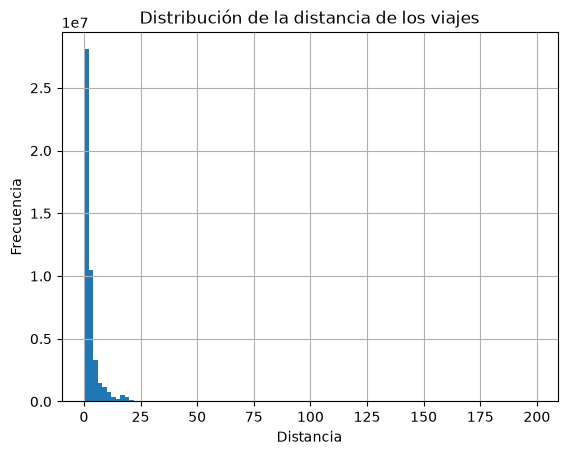

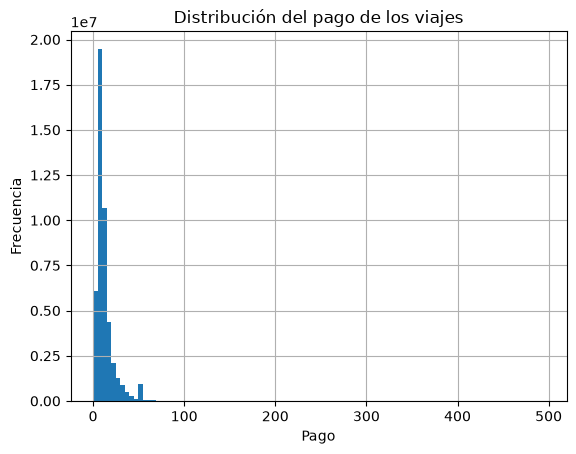

In [60]:
#Análisis de la distancia de los viajes. Vamos a ver cómo se distribuyen las distancias de los viajes en el dataset.
data['trip_distance'].hist(bins=100)
plt.title('Distribución de la distancia de los viajes')
plt.xlabel('Distancia')
plt.ylabel('Frecuencia')
#Análisis del pago de los viajes. Vamos a ver cómo se distribuyen los pagos de los viajes en el dataset.
plt.figure()
data['fare_amount'].hist(bins=100)
plt.xlabel('Pago')
plt.ylabel('Frecuencia')
plt.title('Distribución del pago de los viajes')

In [62]:
#Miremos qué relaciones pueden aparecer entre los pagos y las distancias
import plotly.express as px
px.scatter(x='trip_distance', y='fare_amount', data_frame=data.sample(100000), color='month', size='total_amount', hover_data=['passenger_count', 'payment_type'], title='Relación entre distancia y duración del viaje')

passenger_count
1    7.094137e-01
2    1.424150e-01
3    4.056227e-02
4    1.931954e-02
5    5.415242e-02
6    3.413498e-02
7    7.038946e-07
8    6.825644e-07
9    7.038946e-07
Name: count, dtype: float64


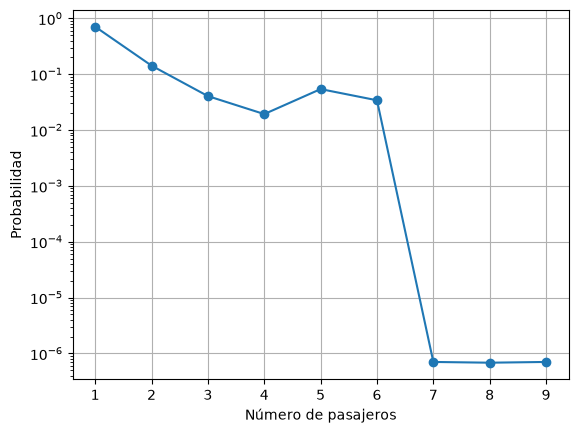

In [69]:
#Hagamos el análisis de probabilidad del número de pasajeros. Vamos a ver cómo se distribuye el número de pasajeros en los viajes del dataset.
cnt=data['passenger_count'].value_counts().sort_index()
pr=cnt/cnt.sum()
plt.semilogy(pr.index, pr.values, marker='o')
plt.ylabel('Probabilidad')
plt.xlabel('Número de pasajeros')
plt.grid()
print(pr)

Probabilidad de no pagar paeajes: 0.9521605084422556


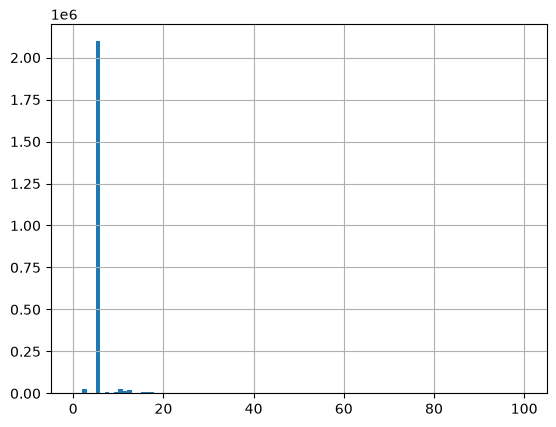

In [77]:
#Hagamos el análisis de probabilidad del valor pagado en peajes en la ruta
print('Probabilidad de no pagar paeajes:', len((data[data['tolls_amount']==0])) / len(data))
cnt=data[data['tolls_amount']>0]['tolls_amount'].hist(bins=100)
